In [1]:
import pandas as pd

# Load Dataset
df = pd.read_csv("Dataset.csv", encoding="latin1")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (9551, 21)


,ï»¿Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [2]:
import pandas as pd

df = pd.read_csv("Dataset.csv", encoding="latin1")

print(df.shape)
df.head()

(9551, 21)


,ï»¿Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [3]:
df[['Restaurant Name','Cuisines','City']].isnull().sum()

Restaurant Name    0
Cuisines           9
City               0
dtype: int64

In [4]:
df = df.dropna(subset=['Cuisines'])

print("Dataset Shape:", df.shape)

Dataset Shape: (9542, 21)


In [5]:
df['Primary Cuisine'] = df['Cuisines'].apply(
    lambda x: x.split(',')[0].strip()
)

df[['Cuisines','Primary Cuisine']].head()

,Cuisines,Primary Cuisine
0,"French, Japanese, Desserts",French
1,Japanese,Japanese
2,"Seafood, Asian, Filipino, Indian",Seafood
3,"Japanese, Sushi",Japanese
4,"Japanese, Korean",Japanese


In [6]:
df['Primary Cuisine'].value_counts().head(15)

Primary Cuisine
North Indian    2992
Chinese          855
Fast Food        672
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Italian          234
Pizza            232
Mughlai          215
Ice Cream        178
Desserts         150
Name: count, dtype: int64

In [7]:
top_cuisines = df['Primary Cuisine'].value_counts().head(10).index

df = df[df['Primary Cuisine'].isin(top_cuisines)]

print(df.shape)
print(df['Primary Cuisine'].value_counts())

(7014, 22)
Primary Cuisine
North Indian    2992
Chinese          855
Fast Food        672
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Name: count, dtype: int64


In [8]:
features = [
    'Country Code',
    'City',
    'Average Cost for two',
    'Price range',
    'Aggregate rating',
    'Votes',
    'Has Table booking',
    'Has Online delivery',
    'Is delivering now'
]

X = df[features]
y = df['Primary Cuisine']

print(X.shape)

(7014, 9)


In [9]:
from sklearn.preprocessing import LabelEncoder

le_city = LabelEncoder()
X['City'] = le_city.fit_transform(X['City'])

X['Has Table booking'] = X['Has Table booking'].map({'Yes':1, 'No':0})
X['Has Online delivery'] = X['Has Online delivery'].map({'Yes':1, 'No':0})
X['Is delivering now'] = X['Is delivering now'].map({'Yes':1, 'No':0})

print(X.head())

    Country Code  City  Average Cost for two  Price range  Aggregate rating  \
5            162    59                  1000            3               4.4   
11           162    71                   900            3               4.2   
15           162    84                   800            3               3.6   
18           162    91                   600            2               4.5   
19           162    91                  1500            4               4.4   

    Votes  Has Table booking  Has Online delivery  Is delivering now  
5     336                  0                    0                  0  
11    488                  1                    0                  0  
15     29                  0                    0                  0  
18    118                  0                    0                  0  
19    392                  1                    0                  0  


C:\Users\Amol\AppData\Local\Temp\ipykernel_5940\238579015.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['City'] = le_city.fit_transform(X['City'])
C:\Users\Amol\AppData\Local\Temp\ipykernel_5940\238579015.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Has Table booking'] = X['Has Table booking'].map({'Yes':1, 'No':0})
C:\Users\Amol\AppData\Local\Temp\ipykernel_5940\238579015.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_i

In [10]:
le_target = LabelEncoder()

y_encoded = le_target.fit_transform(y)

print("Number of Classes:", len(le_target.classes_))
print(le_target.classes_)

Number of Classes: 10
['American' 'Bakery' 'Cafe' 'Chinese' 'Continental' 'Fast Food' 'Mithai'
 'North Indian' 'South Indian' 'Street Food']


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape)
print(X_test.shape)

(5611, 9)
(1403, 9)


In [12]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Training Complete")

Logistic Regression Training Complete


e:\Jupyter NB\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
from sklearn.metrics import accuracy_score, classification_report

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", round(lr_acc,4))

print("\nClassification Report:\n")
print(classification_report(
    y_test,
    lr_pred,
    target_names=le_target.classes_
))

Logistic Regression Accuracy: 0.4547

Classification Report:

              precision    recall  f1-score   support

    American       0.59      0.52      0.55        56
      Bakery       0.00      0.00      0.00       124
        Cafe       0.14      0.01      0.02       123
     Chinese       0.00      0.00      0.00       171
 Continental       0.44      0.09      0.14        47
   Fast Food       0.00      0.00      0.00       135
      Mithai       0.35      0.24      0.29        49
North Indian       0.46      0.98      0.62       599
South Indian       0.00      0.00      0.00        52
 Street Food       0.31      0.11      0.16        47

    accuracy                           0.45      1403
   macro avg       0.23      0.19      0.18      1403
weighted avg       0.27      0.45      0.31      1403



e:\Jupyter NB\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Jupyter NB\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Jupyter NB\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Training Complete")

Random Forest Training Complete


In [15]:
rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_acc,4))

print("\nClassification Report:\n")
print(classification_report(
    y_test,
    rf_pred,
    target_names=le_target.classes_
))

Random Forest Accuracy: 0.4177

Classification Report:

              precision    recall  f1-score   support

    American       0.58      0.55      0.57        56
      Bakery       0.21      0.15      0.17       124
        Cafe       0.36      0.33      0.35       123
     Chinese       0.16      0.10      0.12       171
 Continental       0.21      0.13      0.16        47
   Fast Food       0.22      0.15      0.18       135
      Mithai       0.26      0.22      0.24        49
North Indian       0.53      0.72      0.61       599
South Indian       0.11      0.06      0.07        52
 Street Food       0.24      0.21      0.23        47

    accuracy                           0.42      1403
   macro avg       0.29      0.26      0.27      1403
weighted avg       0.37      0.42      0.38      1403



In [16]:
print("Model Comparison")
print("----------------")
print("Logistic Regression Accuracy :", round(lr_acc,4))
print("Random Forest Accuracy       :", round(rf_acc,4))

Model Comparison
----------------
Logistic Regression Accuracy : 0.4547
Random Forest Accuracy       : 0.4177


                Feature  Importance
5                 Votes    0.387871
4      Aggregate rating    0.201606
2  Average Cost for two    0.194117
1                  City    0.116041
7   Has Online delivery    0.029966
3           Price range    0.029347
0          Country Code    0.026899
6     Has Table booking    0.011322
8     Is delivering now    0.002831


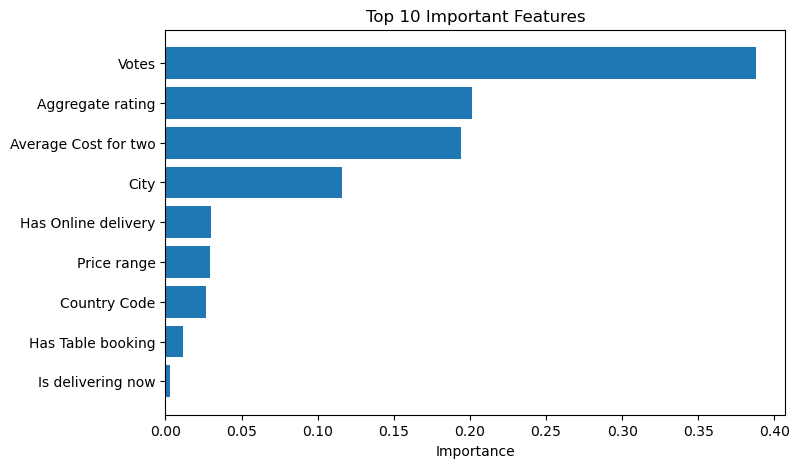

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

plt.figure(figsize=(8,5))
plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

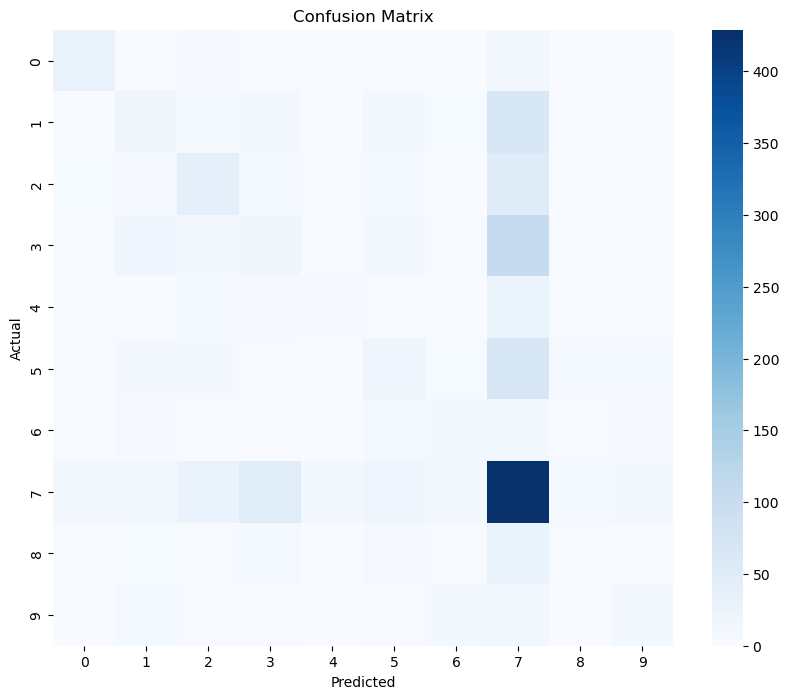

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    cmap="Blues",
    fmt="d"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Conclusion

## Model Performance

Two classification models were trained to predict restaurant cuisines:

| Model | Accuracy |
|---------|---------:|
| Logistic Regression | 45.47% |
| Random Forest | 41.77% |

Logistic Regression achieved the highest classification accuracy and was selected as the final model.

## Key Findings

- North Indian cuisine was predicted more accurately due to having the largest number of samples.
- Minority cuisines such as Continental, South Indian, and Street Food were harder to classify.
- Aggregate Rating, Votes, Average Cost for Two, and Location-related features contributed significantly to cuisine prediction.
- Class imbalance affected model performance because some cuisines had far more training samples than others.

## Challenges and Biases

- The dataset is highly imbalanced across cuisines.
- Similar cuisines often share comparable pricing, ratings, and delivery patterns.
- Some cuisines have limited representation, leading to lower prediction accuracy.

## Future Improvements

- Apply class balancing techniques such as SMOTE.
- Include restaurant name text features using NLP techniques.
- Experiment with advanced models such as XGBoost and Neural Networks.